In [11]:
# --- CELL 1: LIBRARIES AND READING ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import itertools
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read data in
data = pd.read_csv('Manufacturer_RNN_Data.csv')


In [12]:

# --- CELL 2: HYPERPARAMETER CONFIGURATION ---
param_grid = {
    'lookback': [4, 8, 12, 16],
    'hidden': [16, 32, 64, 128],
    'lr': [0.005, 0.001, 0.0005],
    'dropout': [0.1, 0.2],
    'batch_size': [8, 16],
    'epochs': [100]
}
tuning_configs = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]


In [13]:

# --- CELL 3: DATA PREPARATION AND SPLITTING HELPER FUCNTIONS ---

# 1. Encode Manufacturer
data['mfr_idx'] = (data['MANUFACTURER'] == 'BOEING').astype(int)
features = ["TOT_FLY_OPS", "time_from_creation", "mfr_idx", "TOTAL_AIR_HOURS",
            "AIR_DAYS_ASSIGN", "AIR_FUELS_ISSUED", "AIRFRAME_LABOR", "ENGINE_LABOR",
            "AIRFRAME_OVERHAULS", "ENGINE_OVERHAULS", "N_CARRIERS", "UTILISATION"]

target = "MAINT_PER_AIR_HR"

# Select only the columns that actually need scaling
cols_to_scale = ["TOT_FLY_OPS", "time_from_creation", "TOTAL_AIR_HOURS",
            "AIR_DAYS_ASSIGN", "AIR_FUELS_ISSUED", "AIRFRAME_LABOR", "ENGINE_LABOR",
            "AIRFRAME_OVERHAULS", "ENGINE_OVERHAULS", "N_CARRIERS", "UTILISATION"]

# 2. Chronological Scaling (Preventing Data Leakage)
train_split_idx = int(len(data) * 0.80)
scaler = StandardScaler()
scaler.fit(data.iloc[:train_split_idx][features])

# Scale only those, and re-attach them to the unscaled IDs
data_scaled = data.copy()
data_scaled[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

# ------ DEBUG LINE ----------
# print(data_scaled)
# ----------------------------

# 3. Sequence Generation Function
def create_mfr_sequences(df, lookback):
    X, y = [], []
    # Process each manufacturer separately to maintain sequence integrity
    for mfr in [0, 1]:
        mfr_data = df[df['mfr_idx'] == mfr].sort_values('TIME_POINT')
        vals = mfr_data[features + [target]].values
# ------ DEBUG LINE ----------
        #print(df.columns.tolist())
        #print(df['mfr_idx'].dtype)

        # Isolated Test: Does the filter actually return rows?
        #test_mfr_0 = data[data['mfr_idx'] == 0]
        #test_mfr_1 = data[data['mfr_idx'] == 1]

        #print(f"Filter for 0 returned: {len(test_mfr_0)} rows")
        #print(f"Filter for 1 returned: {len(test_mfr_1)} rows")
        #print(f"Unique values in mfr_idx: {data['mfr_idx'].unique()}")
# ----------------------------

        if len(vals) > lookback:
            for i in range(len(vals) - lookback):
                X.append(vals[i : i + lookback, :-1])
                y.append(vals[i + lookback, -1])


    return np.array(X), np.array(y)

def get_split_sequences(df_scaled, lookback):
    X, y = create_mfr_sequences(df_scaled, lookback)
    n = len(X)
    tr_idx = int(n * 0.8)
    vl_idx = int(n * 0.9)

# ----- DEBUG LINE ------
    #print(f"Total sequences created: {len(X)}")
    #print(f"Indices: Train {0}-{tr_idx}, Val {tr_idx+1}-{vl_idx}, Test {vl_idx+1}-{n}")
# -----------------------

    return (X[:tr_idx], y[:tr_idx]), (X[tr_idx+1:vl_idx], y[tr_idx+1:vl_idx]), (X[vl_idx+1:], y[vl_idx+1:])


In [14]:

# --- CELL 4: Model Architecture & Evaluation ---

class MfrLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        return self.fc(out)


In [15]:

# --- CELL 5: TRAINING AND EVALUATION FUNCTIONS ---

def evaluate_model(model, X_data, y_data, criterion):
# ----- DEBUG LINE ------
    # print(f"DEBUG: X_data type: {type(X_data)}")
    # print(f"DEBUG: Initial shape: {getattr(X_data, 'shape', 'No shape attr')}")
# -----------------------
    model.eval()
    with torch.no_grad():
        # Ensure input is 3D: [Number of Samples, Lookback, Features]
        inputs = torch.tensor(X_data).to(device).float()

        # If X_data was [Lookback, Features] (1 sample), we must add the batch dimension
        if inputs.dim() == 2:
            inputs = inputs.unsqueeze(0)

        targets = torch.tensor(y_data).to(device).float().unsqueeze(1)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        return loss.item()

def train_robust_model(config, config_id):
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = get_split_sequences(data_scaled, config['lookback'])

    train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=config['batch_size'], shuffle=False)
    model = MfrLSTM(len(features), config['hidden'], config['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    # Create a unique filename for this specific hyperparameter set
    temp_filename = f'model_cfg_{config_id}.pth'

    for epoch in range(config['epochs']):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device).float(), by.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()

        current_val_loss = evaluate_model(model, X_val, y_val, criterion)
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            torch.save(model.state_dict(), temp_filename)

    # Load the best state FOR THIS CONFIG to run the robustness test
    model.load_state_dict(torch.load(temp_filename))
    test_robustness_loss = evaluate_model(model, X_test, y_test, criterion)

    return best_val_loss, test_robustness_loss, temp_filename


In [16]:

# --- CELL 6: TRAINING LOOP ---

print(f"{'Config':<50} | {'Val Loss':<10} | {'Test Loss (Robustness)':<10}")
print("-" * 85)

results = []
absolute_best_test_loss = float('inf')
best_model_filename = ""

for i, cfg in enumerate(tuning_configs):
    v_loss, t_loss, cfg_file = train_robust_model(cfg, i)
    results.append({'config': cfg, 'val_loss': v_loss, 'test_loss': t_loss, 'file': cfg_file})

    # Check if this is the global winner based on Test MSE
    if t_loss < absolute_best_test_loss:
        absolute_best_test_loss = t_loss
        best_model_filename = cfg_file

    print(f"{str(cfg):<50} | {v_loss:<10.5f} | {t_loss:<10.5f}")

# Final Step: Promote the winner and cleanup
final_path = 'final_best_model.pth'
os.rename(best_model_filename, final_path)

# Cleanup: Delete the other temporary files
for res in results:
    if res['file'] != best_model_filename and os.path.exists(res['file']):
        os.remove(res['file'])

print(f"\nTraining Complete. Global best model (Test MSE: {absolute_best_test_loss:.5f}) saved as {final_path}")

Config                                             | Val Loss   | Test Loss (Robustness)
-------------------------------------------------------------------------------------
{'lookback': 4, 'hidden': 16, 'lr': 0.005, 'dropout': 0.1, 'batch_size': 8, 'epochs': 100} | 0.01696    | 0.01032   
{'lookback': 4, 'hidden': 16, 'lr': 0.005, 'dropout': 0.1, 'batch_size': 16, 'epochs': 100} | 0.01534    | 0.03843   
{'lookback': 4, 'hidden': 16, 'lr': 0.005, 'dropout': 0.2, 'batch_size': 8, 'epochs': 100} | 0.04699    | 0.02577   
{'lookback': 4, 'hidden': 16, 'lr': 0.005, 'dropout': 0.2, 'batch_size': 16, 'epochs': 100} | 0.03482    | 0.01525   
{'lookback': 4, 'hidden': 16, 'lr': 0.001, 'dropout': 0.1, 'batch_size': 8, 'epochs': 100} | 0.03446    | 0.03327   
{'lookback': 4, 'hidden': 16, 'lr': 0.001, 'dropout': 0.1, 'batch_size': 16, 'epochs': 100} | 0.06434    | 0.05220   
{'lookback': 4, 'hidden': 16, 'lr': 0.001, 'dropout': 0.2, 'batch_size': 8, 'epochs': 100} | 0.09682    | 0.03484   
{'l

Loading model with hidden_dim: 128 to match saved checkpoint.


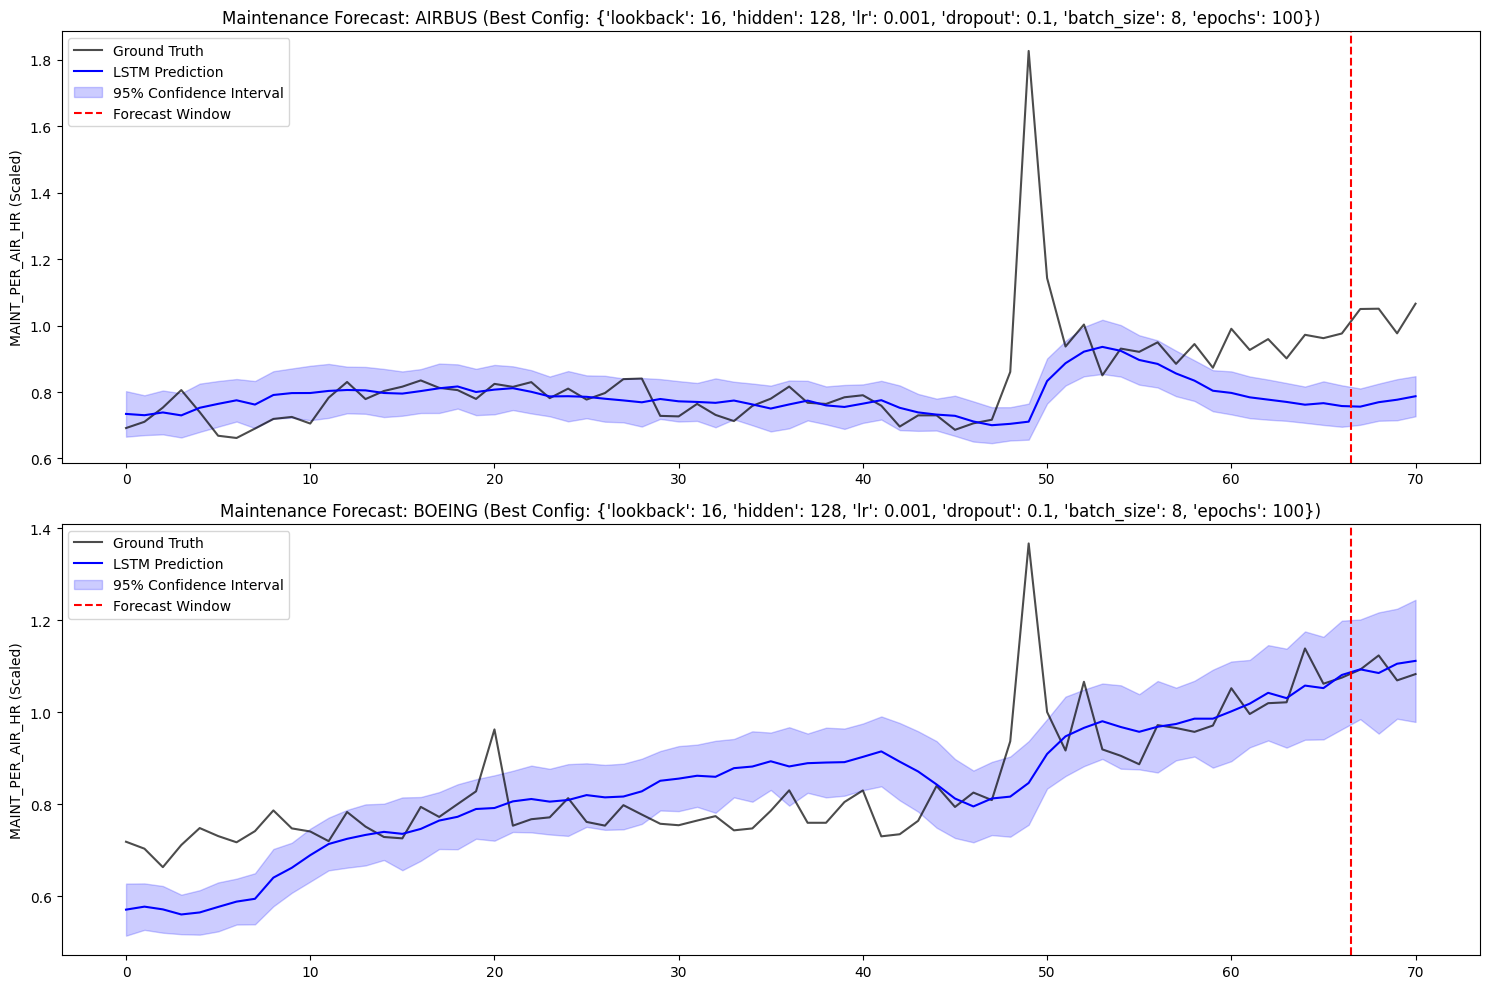

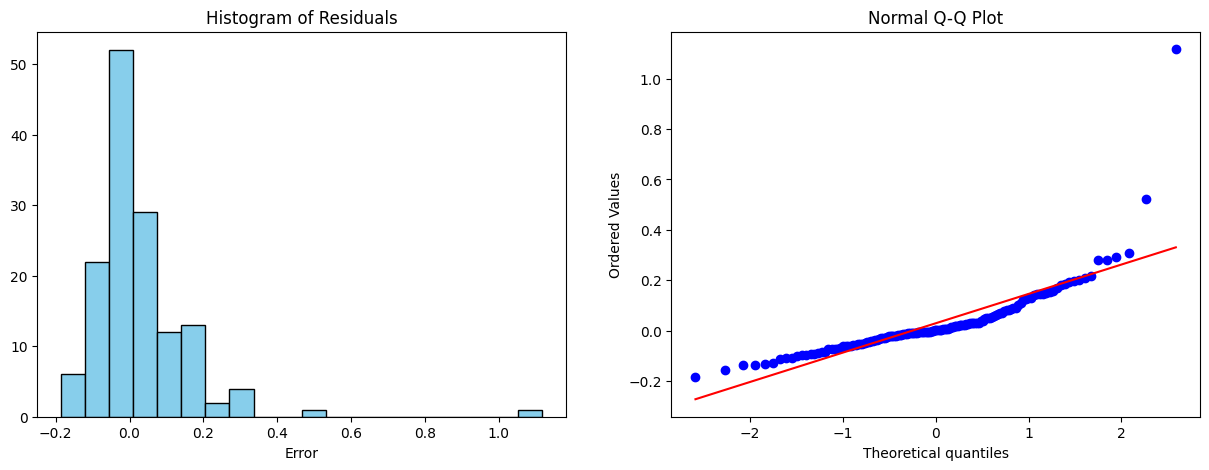


--- Statistical Diagnostics ---
Shapiro-Wilk Test: W=0.7127, p-value=0.0000
Result: Residuals are NOT Normally Distributed (Reject H0)
Success: Final 7 predictions for both companies exported to 'manufacturer_forecasts.csv'
   Manufacturer Forecast_Horizon  Predicted_MAINT_PER_AIR_HR
0        AIRBUS              T+1                      1.0570
1        AIRBUS              T+2                      1.0635
2        AIRBUS              T+3                      1.0759
3        AIRBUS              T+4                      1.0897
4        AIRBUS              T+5                      1.1011
5        AIRBUS              T+6                      1.1071
6        AIRBUS              T+7                      1.1067
7        BOEING              T+1                      1.0570
8        BOEING              T+2                      1.0635
9        BOEING              T+3                      1.0759
10       BOEING              T+4                      1.0897
11       BOEING              T+5           

In [17]:
# --- CELL 7: VISUALIZATION AND RESIDUAL DIAGNOSTICS ---

def get_predictions_with_uncertainty(model, X_data, iterations=100):
    model.train() # Keep dropout active for uncertainty
    preds = []
    inputs = torch.tensor(X_data).to(device).float()

    with torch.no_grad():
        for _ in range(iterations):
            preds.append(model(inputs).cpu().numpy())

    preds = np.array(preds).squeeze() # Shape: [Iterations, Samples]
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    # 95% Confidence Interval is approx 1.96 * Standard Deviation
    return mean_pred, 1.96 * std_pred

best_run = min(results, key=lambda x: x['test_loss'])
best_cfg = best_run['config']
lookback = best_cfg['lookback']

X_all, y_all = create_mfr_sequences(data_scaled, lookback)

# Extract the specific hidden dimension that matches the saved .pth file
hidden_dim = best_cfg['hidden']
input_dim = len(features)
dropout = best_cfg['dropout']

print(f"Loading model with hidden_dim: {hidden_dim} to match saved checkpoint.")

# Initialize model with the CORRECT dimensions
model = MfrLSTM(input_dim, hidden_dim, dropout).to(device)

# Now loading will work perfectly
model.load_state_dict(torch.load('final_best_model.pth'))
model.eval()

# 3. Generate Predictions for both Manufacturers
mfr_names = {0: 'AIRBUS', 1: 'BOEING'}
mfr_col_idx = features.index("mfr_idx")

all_residuals = []

plt.figure(figsize=(15, 10))

for i, mfr in enumerate([0, 1]):
    # Get mask for this manufacturer in the sequence data
    # (Checking the last time step's mfr_idx)
    mfr_mask = (X_all[:, -1, mfr_col_idx] == mfr)
    X_mfr = X_all[mfr_mask]
    y_mfr = y_all[mfr_mask]

    means, intervals = get_predictions_with_uncertainty(model, X_mfr)
    all_residuals.extend(y_mfr - means)

    # Plotting
    plt.subplot(2, 1, i+1)
    time_steps = np.arange(len(y_mfr))

    # Ground Truth vs Prediction
    plt.plot(time_steps, y_mfr, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(time_steps, means, label='LSTM Prediction', color='blue')

    # 95% CI Band
    plt.fill_between(time_steps, means - intervals, means + intervals,
                     color='blue', alpha=0.2, label='95% Confidence Interval')

    # Forecast Boundary (Dotted line for last 4 outputs)
    plt.axvline(x=len(y_mfr)-4.5, color='red', linestyle='--', label='Forecast Window')

    plt.title(f"Maintenance Forecast: {mfr_names[mfr]} (Best Config: {best_cfg})")
    plt.ylabel("MAINT_PER_AIR_HR (Scaled)")
    plt.legend()

plt.tight_layout()
plt.show()

# 4. Residual Diagnostics
all_residuals = np.array(all_residuals)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
ax[0].hist(all_residuals, bins=20, color='skyblue', edgecolor='black')
ax[0].set_title("Histogram of Residuals")
ax[0].set_xlabel("Error")

# QQ-Plot
stats.probplot(all_residuals, dist="norm", plot=ax[1])
ax[1].set_title("Normal Q-Q Plot")

plt.show()

# Shapiro-Wilk Test
sw_stat, sw_p = stats.shapiro(all_residuals)
print(f"\n--- Statistical Diagnostics ---")
print(f"Shapiro-Wilk Test: W={sw_stat:.4f}, p-value={sw_p:.4f}")
if sw_p > 0.05:
    print("Result: Residuals appear Normally Distributed (Fail to reject H0)")
else:
    print("Result: Residuals are NOT Normally Distributed (Reject H0)")

# --- CELL 8: Export Final Forecasts to CSV ---

forecast_results = []
lookback = best_cfg['lookback']

# We will look at the last 7 sequences available for each manufacturer
num_forecasts = 7

model.eval()
with torch.no_grad():
    for mfr_val, mfr_name in {0: 'AIRBUS', 1: 'BOEING'}.items():
        # 1. Isolate the data for this manufacturer
        mfr_mask = (X_all[:, -1, mfr_col_idx] == mfr)
        X_mfr = X_all[mfr_mask]

        # 2. Get the last 7 windows
        last_windows = torch.tensor(X_mfr[-num_forecasts:]).to(device).float()

        # 3. Predict (using the mean prediction without dropout for stability)
        raw_preds = model(last_windows).cpu().numpy()

        # 4. Inverse Scale the predictions
        # Note: Scaler expects [TOT_FLY_OPS, time_from_creation]
        # Since our target variable was NOT part of the feature scaler,
        # but the target depends on those features, we need to handle the target scaling specifically.
        # If you scaled the target separately, use target_scaler.inverse_transform here.
        # If target was unscaled, raw_preds are already in real units.

        final_vals = raw_preds.flatten()

        # 5. Build the list for the CSV
        for i, val in enumerate(final_vals):
            forecast_results.append({
                'Manufacturer': mfr_name,
                'Forecast_Horizon': f'T+{i+1}',
                'Predicted_MAINT_PER_AIR_HR': round(val, 4)
            })

# 6. Create DataFrame and Export
df_forecast = pd.DataFrame(forecast_results)
df_forecast.to_csv('manufacturer_forecasts.csv', index=False)

print("Success: Final 7 predictions for both companies exported to 'manufacturer_forecasts.csv'")
print(df_forecast)
model_parameters = sum(p.numel() for p in model.parameters())
print(f"Model Parameter Count: {model_parameters}")

/tmp/ipykernel_18584/3661026637.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


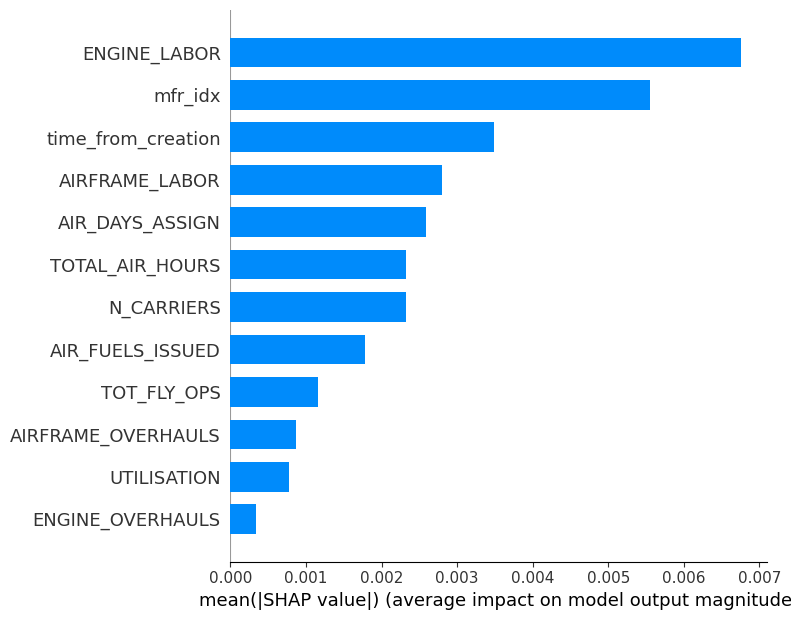

In [18]:
# --- CELL 8: SHAP VALUES ---

import shap

# 1. Prepare background data
background_indices = np.random.choice(X_all.shape[0], 100, replace=False)
background_data = torch.tensor(X_all[background_indices]).to(device).float()

# 2. THE FIX: Disable cuDNN optimizations temporarily
# This forces the LSTM to use a version that allows gradient calculation
torch.backends.cudnn.enabled = False

# Set model to train but keep Dropout off
model.train()
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

# 3. Initialize the Explainer
# GradientExplainer is best for LSTMs
explainer = shap.GradientExplainer(model, background_data)

# 4. Select samples and compute SHAP values
test_samples = torch.tensor(X_all[-10:]).to(device).float()
shap_values = explainer.shap_values(test_samples)

# 5. Re-enable cuDNN when finished
torch.backends.cudnn.enabled = True
model.eval()

# 6. Visualization
# We aggregate the 3D SHAP values [Samples, Time, Features] into 2D [Samples, Features]
shap_values_array = np.array(shap_values)
# Average the magnitude across the time/lookback dimension
shap_values_2d = np.mean(np.abs(shap_values_array), axis=1).squeeze()

shap.summary_plot(
    shap_values_2d,
    features=features,
    plot_type="bar"
)